# Análisis de Distancia — Termalización AmBe
Cómo afecta la distancia fuente–parafina a la termalización, detección y tasa de neutrones.
Se comparan distintas geometrías de parafina.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

BUILD_DIR = os.path.abspath('../build')
CSV_PATH  = os.path.join(BUILD_DIR, 'resultados_ambe.csv')

df = pd.read_csv(CSV_PATH)
df['Efic_deteccion_%'] = df['Neutrones'] / df['BeamOn'] * 100
df['Area_frontal_cm2'] = df['Ancho_cm'] * df['Alto_cm']
df['Cara_cuadrada']    = df['Ancho_cm'] == df['Alto_cm']
df['Tasa_term_ps']     = df['Tasa_n_det_ps'] * df['Frac_termica_%'] / 100

BEAM_ON  = int(df['BeamOn'].iloc[0])
ACTIVITY = float(df['Actividad_Ci'].iloc[0])
distancias = sorted(df['Distancia_cm'].unique())
espesores  = sorted(df['Espesor_cm'].unique())

print(f'Configuraciones: {len(df)}')
print(f'Distancias (cm): {distancias}')
print(f'Espesores  (cm): {espesores}')
df.head(3)

Configuraciones: 36
Distancias (cm): [np.float64(5.0), np.float64(10.0), np.float64(20.0)]
Espesores  (cm): [np.float64(10.0), np.float64(20.0), np.float64(30.0)]


,Ancho_cm,Alto_cm,Espesor_cm,Distancia_cm,BeamOn,Actividad_Ci,Duracion_s,Total_detectados,Neutrones,Gammas,...,Otros,N_termicos,N_epitermicos,N_rapidos,Frac_termica_%,Tasa_n_det_ps,Efic_deteccion_%,Area_frontal_cm2,Cara_cuadrada,Tasa_term_ps
0,10.0,10.0,10.0,5.0,50000,2.98,4.6,103,45,55,...,0,1,22,22,2.22,5900.40,0.090,100.0,True,130.98888
1,10.0,10.0,10.0,10.0,50000,2.98,3.0,53,26,25,...,0,0,8,18,0.00,3409.12,0.052,100.0,True,0.00000
2,10.0,10.0,10.0,20.0,50000,2.98,2.2,23,9,14,...,0,0,4,5,0.00,1180.08,0.018,100.0,True,0.00000


## 1. Fracción de termalización vs Distancia
Una línea por espesor de parafina. Se usa la cara cuadrada más grande disponible para maximizar estadística.

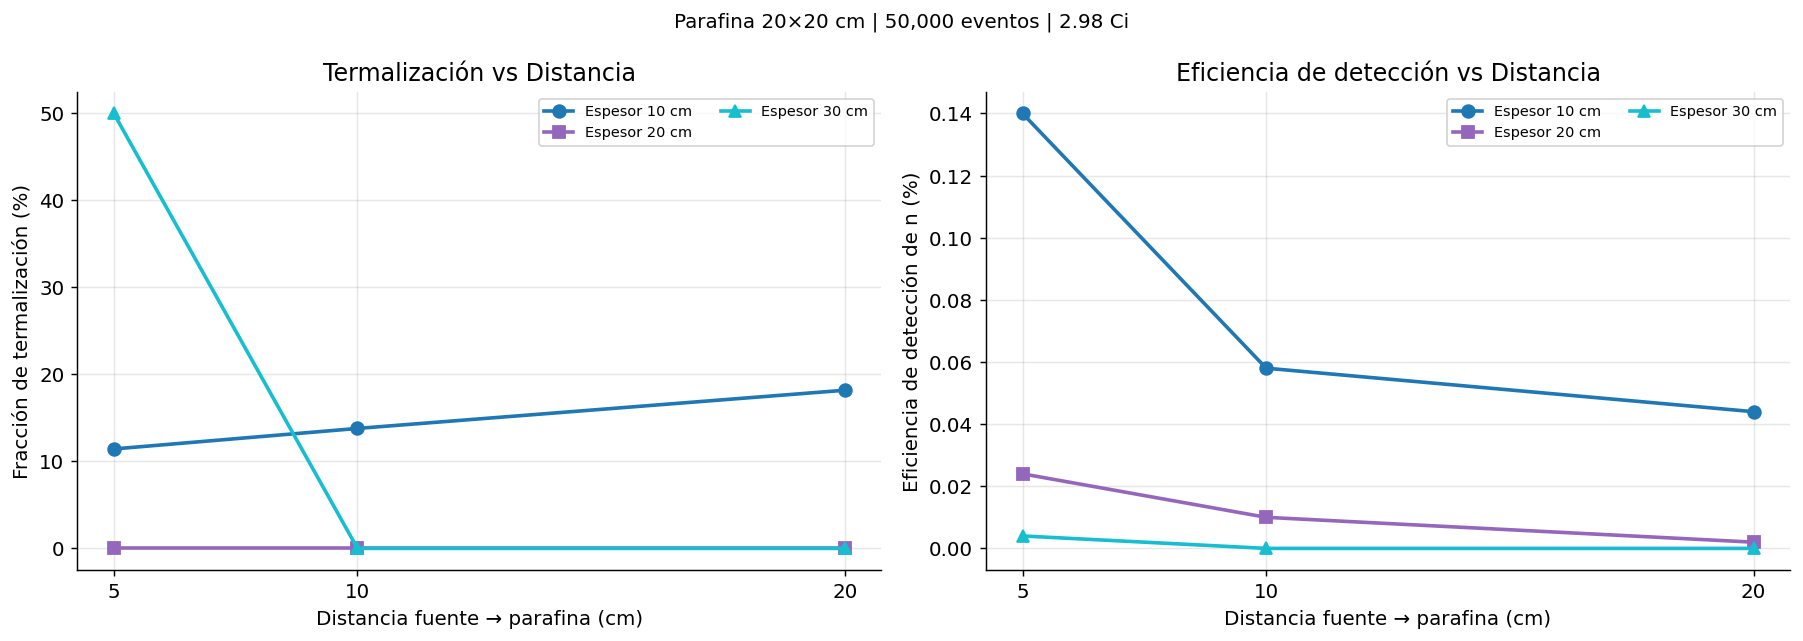

In [2]:
# Cara cuadrada más grande disponible
sq = df[df['Cara_cuadrada']]
lado_max = sq['Ancho_cm'].max()
ref = sq[sq['Ancho_cm'] == lado_max].copy()

paleta = plt.cm.tab10(np.linspace(0, 0.9, len(espesores)))
markers = ['o','s','^','D','v','<','>','p','*','h','+']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for esp, col, mk in zip(espesores, paleta, markers):
    row = ref[ref.Espesor_cm == esp].sort_values('Distancia_cm')
    if row.empty:
        continue
    lbl = f'Espesor {esp:.0f} cm'
    ax1.plot(row.Distancia_cm, row['Frac_termica_%'],
             marker=mk, color=col, lw=2, ms=7, label=lbl)
    ax2.plot(row.Distancia_cm, row['Efic_deteccion_%'],
             marker=mk, color=col, lw=2, ms=7, label=lbl)

ax1.set_xlabel('Distancia fuente → parafina (cm)')
ax1.set_ylabel('Fracción de termalización (%)')
ax1.set_title('Termalización vs Distancia')
ax1.set_xticks(distancias); ax1.legend(fontsize=8, ncol=2)

ax2.set_xlabel('Distancia fuente → parafina (cm)')
ax2.set_ylabel('Eficiencia de detección de n (%)')
ax2.set_title('Eficiencia de detección vs Distancia')
ax2.set_xticks(distancias); ax2.legend(fontsize=8, ncol=2)

plt.suptitle(f'Parafina {int(lado_max)}×{int(lado_max)} cm | {BEAM_ON:,} eventos | {ACTIVITY} Ci',
             fontsize=11)
plt.tight_layout(); plt.show()

## 2. Tasa de neutrones en detector vs Distancia
Tasa total y tasa de neutrones térmicos, estimadas con la actividad de la fuente.

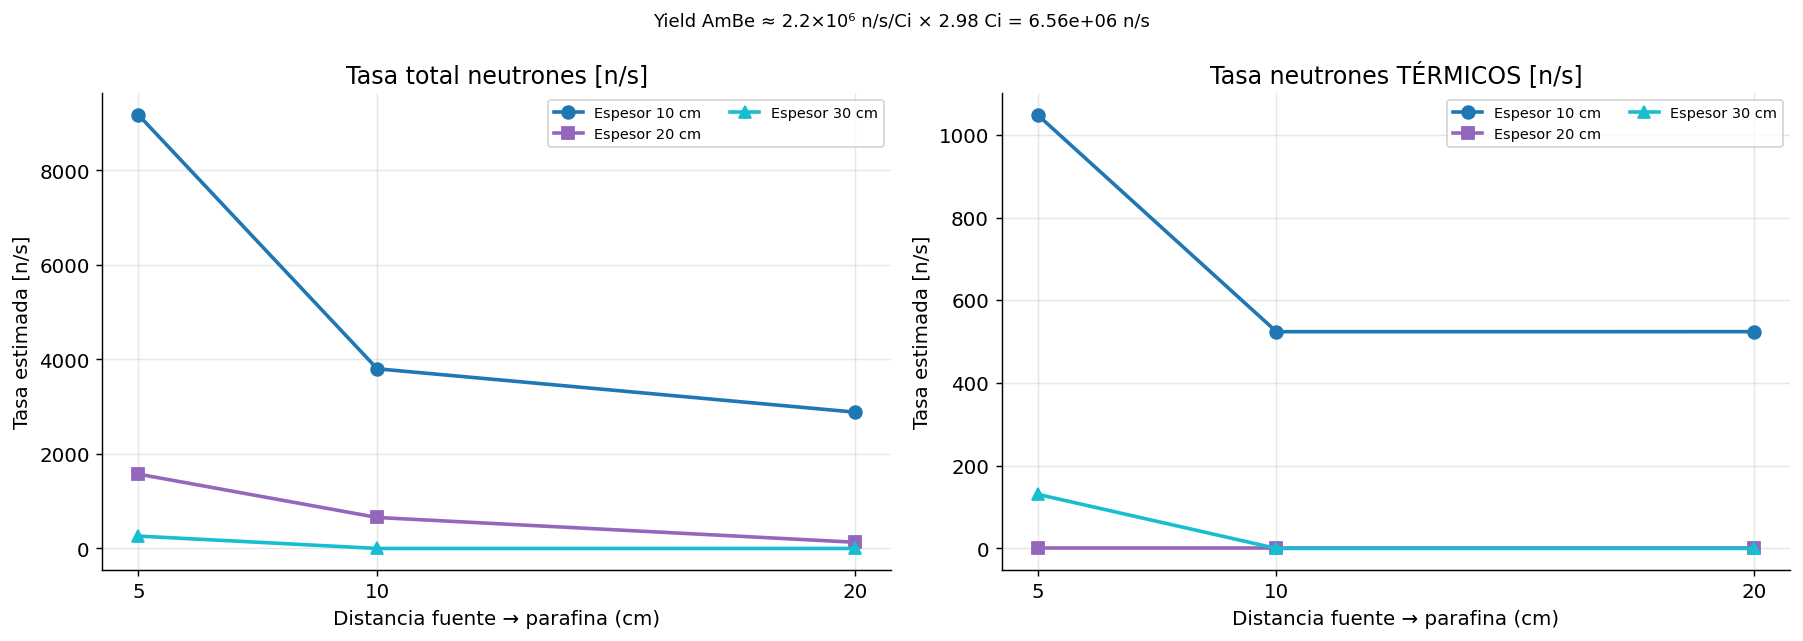

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for esp, col, mk in zip(espesores, paleta, markers):
    row = ref[ref.Espesor_cm == esp].sort_values('Distancia_cm')
    if row.empty:
        continue
    lbl = f'Espesor {esp:.0f} cm'
    ax1.plot(row.Distancia_cm, row['Tasa_n_det_ps'],
             marker=mk, color=col, lw=2, ms=7, label=lbl)
    ax2.plot(row.Distancia_cm, row['Tasa_term_ps'],
             marker=mk, color=col, lw=2, ms=7, label=lbl)

for ax, titulo in zip((ax1, ax2),
                      ('Tasa total neutrones [n/s]', 'Tasa neutrones TÉRMICOS [n/s]')):
    ax.set_xlabel('Distancia fuente → parafina (cm)')
    ax.set_ylabel('Tasa estimada [n/s]')
    ax.set_title(titulo)
    ax.set_xticks(distancias)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle(f'Yield AmBe ≈ 2.2×10⁶ n/s/Ci × {ACTIVITY} Ci = {ACTIVITY*2.2e6:.2e} n/s',
             fontsize=10)
plt.tight_layout(); plt.show()

## 3. Efecto combinado: Área frontal y Distancia
Para un espesor fijo, cómo cambia la detección con el área de la cara y la distancia.

Espesor de referencia: 10.0 cm (mayor frac. térmica promedio)


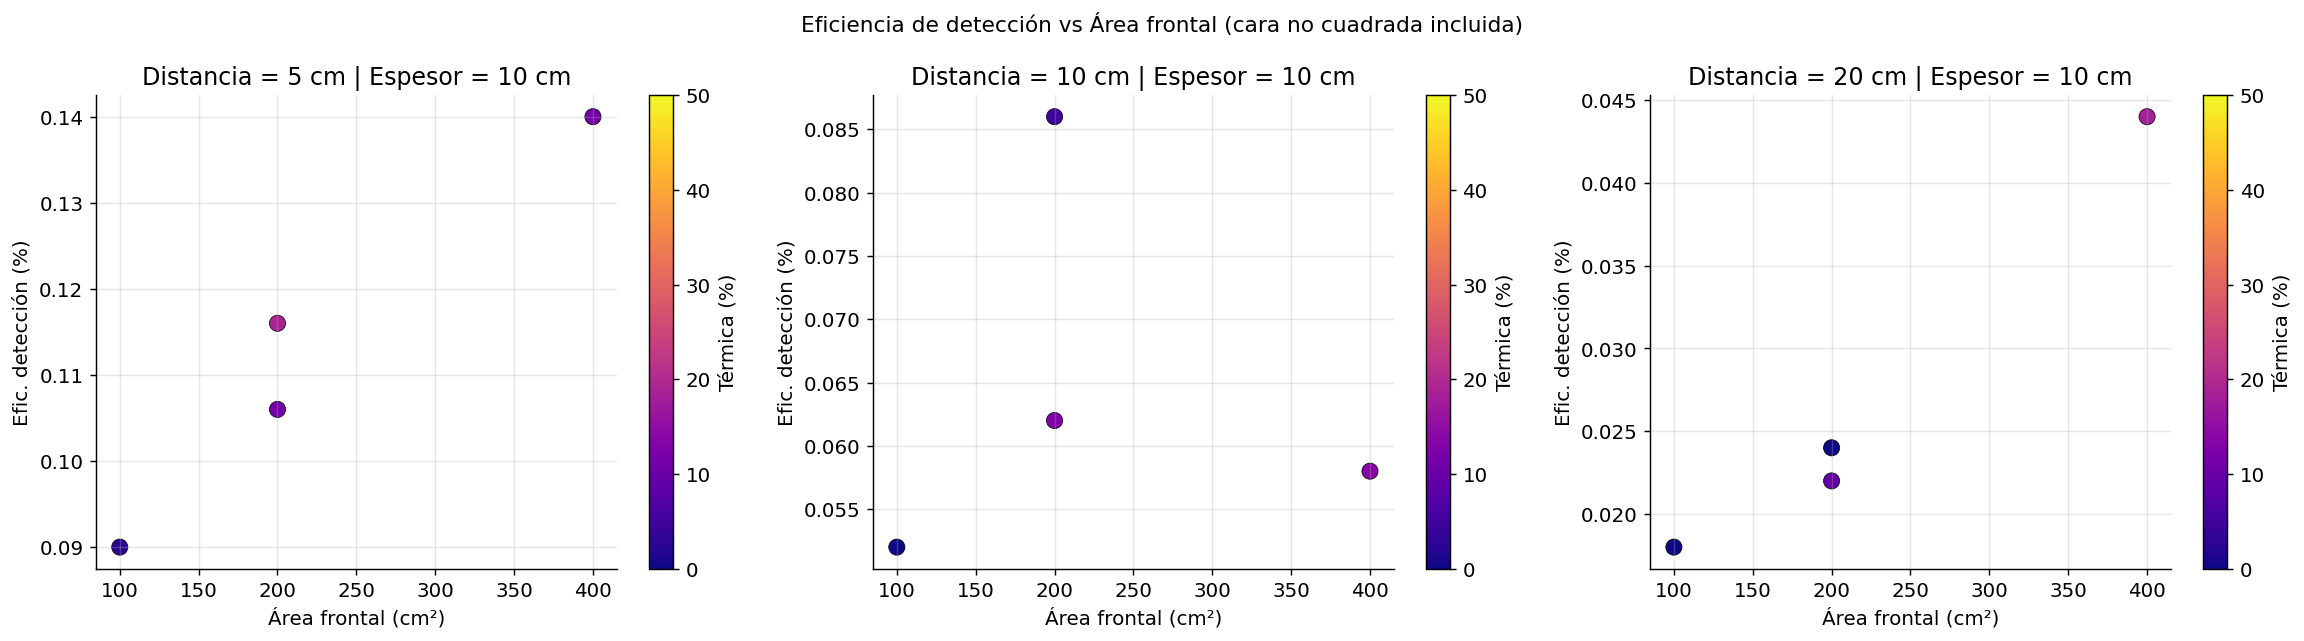

In [4]:
# Espesor de referencia: el que más termaliza en el primer dataset
esp_ref = df.groupby('Espesor_cm')['Frac_termica_%'].mean().idxmax()
print(f'Espesor de referencia: {esp_ref} cm (mayor frac. térmica promedio)')

sub = df[df.Espesor_cm == esp_ref].copy()

fig, axes = plt.subplots(1, len(distancias), figsize=(6*len(distancias), 5))
if len(distancias) == 1:
    axes = [axes]

for ax, dist in zip(axes, distancias):
    s = sub[sub.Distancia_cm == dist]
    if s.empty:
        continue
    sc = ax.scatter(s['Area_frontal_cm2'], s['Efic_deteccion_%'],
                    c=s['Frac_termica_%'], cmap='plasma',
                    s=80, edgecolors='k', linewidths=0.4,
                    vmin=0, vmax=df['Frac_termica_%'].max() or 1)
    plt.colorbar(sc, ax=ax, label='Térmica (%)')
    ax.set_xlabel('Área frontal (cm²)')
    ax.set_ylabel('Efic. detección (%)')
    ax.set_title(f'Distancia = {int(dist)} cm | Espesor = {esp_ref:.0f} cm')

plt.suptitle('Eficiencia de detección vs Área frontal (cara no cuadrada incluida)', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Distribución de energías: misma geometría, distintas distancias
Muestra cómo cambia el espectro al alejar la fuente.

In [5]:
def root_path(ancho, alto, espesor, dist):
    return os.path.join(BUILD_DIR,
        f'AmBe_{int(ancho)}x{int(alto)}x{int(espesor)}cm_d{int(dist)}cm.root')

part_cfg = {
    'neutron': ('#1565C0', 'Neutrón'),
    'gamma':   ('#E65100', 'Gamma'),
    'e-':      ('#2E7D32', 'e⁻'),
}
bins = np.logspace(-3, 7, 80)

# Usar la cara cuadrada más grande y el espesor de referencia
ancho = alto = lado_max
# Elige hasta 3 espesores para comparar
esps_plot = espesores[:min(3, len(espesores))]

for esp in esps_plot:
    disponibles = [(dist, root_path(ancho, alto, esp, dist))
                   for dist in distancias if os.path.exists(root_path(ancho, alto, esp, dist))]
    if not disponibles:
        print(f'No hay ROOTs para espesor {esp} cm')
        continue

    fig, axes = plt.subplots(1, len(disponibles), figsize=(5*len(disponibles), 4))
    if len(disponibles) == 1:
        axes = [axes]

    for ax, (dist, path) in zip(axes, disponibles):
        with uproot.open(path) as f:
            arr = f['PhaseSpace'].arrays(['Particle','KinE_eV'], library='np')
        for pname, (col, lbl) in part_cfg.items():
            mask = arr['Particle'] == pname
            if not mask.any():
                continue
            ax.hist(arr['KinE_eV'][mask], bins=bins, histtype='stepfilled',
                    alpha=0.5, color=col, label=f'{lbl} ({mask.sum()})')
            ax.hist(arr['KinE_eV'][mask], bins=bins, histtype='step', color=col, lw=1.5)
        ax.axvline(0.025, color='k', ls='--', lw=1.2, label='E_térmica')
        ax.set_xscale('log')
        ax.set_xlabel('Energía (eV)')
        ax.set_ylabel('Cuentas')
        ax.set_title(f'Distancia {int(dist)} cm')
        ax.legend(fontsize=7)

    plt.suptitle(f'Espectro de energías — Parafina {int(ancho)}×{int(alto)}×{int(esp)} cm',
                 fontsize=12)
    plt.tight_layout(); plt.show()

No hay ROOTs para espesor 10.0 cm
No hay ROOTs para espesor 20.0 cm
No hay ROOTs para espesor 30.0 cm


## 5. Tabla resumen — Mejor configuración por distancia
Geometría que maximiza neutrones térmicos en el detector, para cada distancia.

In [6]:
resumen = []
for dist in distancias:
    sub = df[df.Distancia_cm == dist]
    # Mejor: más neutrones térmicos absolutos
    mejor = sub.loc[sub['N_termicos'].idxmax()]
    resumen.append({
        'Distancia_cm':  dist,
        'Ancho_cm':      mejor.Ancho_cm,
        'Alto_cm':       mejor.Alto_cm,
        'Espesor_cm':    mejor.Espesor_cm,
        'N_termicos':    mejor.N_termicos,
        'Frac_termica_%': mejor['Frac_termica_%'],
        'Efic_detec_%':  round(mejor['Efic_deteccion_%'], 4),
        'Tasa_term_ps':  mejor.Tasa_term_ps,
    })

df_res = pd.DataFrame(resumen)
print('Mejor geometría por distancia (máximo n térmicos detectados):')
display(df_res.set_index('Distancia_cm'))

Mejor geometría por distancia (máximo n térmicos detectados):


,Ancho_cm,Alto_cm,Espesor_cm,N_termicos,Frac_termica_%,Efic_detec_%,Tasa_term_ps
Distancia_cm,,,,,,,
5.0,10.0,20.0,10.0,11,18.97,0.116,1442.660912
10.0,10.0,20.0,10.0,4,12.90,0.062,524.348880
20.0,20.0,20.0,10.0,4,18.18,0.044,524.427552
